### **Bag of Words**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

sample_reviews = [
    "this movie was great and the acting was great",
    "this movie was boring and too long",
    "great acting, terrible story"
]

vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(sample_reviews)

print(vectorizer.get_feature_names_out())
print(bow_matrix.toarray())

['acting' 'and' 'boring' 'great' 'long' 'movie' 'story' 'terrible' 'the'
 'this' 'too' 'was']
[[1 1 0 2 0 1 0 0 1 1 0 2]
 [0 1 1 0 1 1 0 0 0 1 1 1]
 [1 0 0 1 0 0 1 1 0 0 0 0]]


### **TF-IDF**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_reviews)

print(tfidf_vectorizer.get_feature_names_out())
print(tfidf_matrix.toarray().round(2))

['acting' 'and' 'boring' 'great' 'long' 'movie' 'story' 'terrible' 'the'
 'this' 'too' 'was']
[[0.27 0.27 0.   0.54 0.   0.27 0.   0.   0.35 0.27 0.   0.54]
 [0.   0.33 0.43 0.   0.43 0.33 0.   0.   0.   0.33 0.43 0.33]
 [0.43 0.   0.   0.43 0.   0.   0.56 0.56 0.   0.   0.   0.  ]]


### **Introduction to Embeddings**

In [ ]:
! pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 69.8 MB/s eta 0:00:00


In [ ]:
import gensim.downloader as api

word_vectors = api.load("glove-wiki-gigaword-100")

print(word_vectors.most_similar("movie", topn=5))

[==================================================] 100.0% 128.1/128.1MB downloaded
[('film', 0.9055121541023254), ('movies', 0.8959327340126038), ('films', 0.866355299949646), ('hollywood', 0.8239826560020447), ('comedy', 0.8141382932662964)]


### **Logistic Regression**

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

df = pd.read_csv("IMDB Dataset.csv")

X_text = df['review']
y = df['sentiment']

tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_tfidf = tfidf.fit_transform(X_text)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

### **Accuracy**

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, predictions)
print("Accuracy:", acc)

Accuracy: 0.8896


### **Recall**

In [ ]:
from sklearn.metrics import recall_score

rec = recall_score(y_test, predictions, pos_label='positive')
print("Recall:", rec)

Recall: 0.9053383607858703


### **Precision**

In [ ]:
from sklearn.metrics import precision_score

prec = precision_score(y_test, predictions, pos_label='positive')
print("Precision:", prec)

Precision: 0.879167469647331


### **F1 Score**

In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, predictions, pos_label='positive')
print("F1 Score:", f1)

F1 Score: 0.8920610089949159


### **Confusion Matrix**

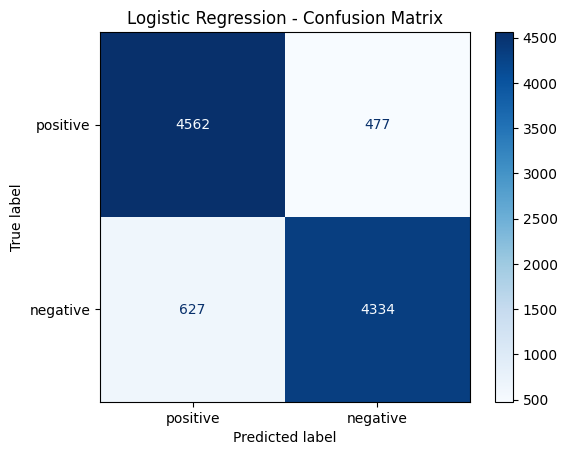

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions, labels=['positive', 'negative'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['positive', 'negative'])
disp.plot(cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

### **Naive Bayes**

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

df = pd.read_csv("spam.csv", encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print(df.shape)
print(df.head())
print(df['label'].value_counts())

(5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
label
ham     4825
spam     747
Name: count, dtype: int64


In [ ]:
X_text = df['message']
y = df['label']

tfidf = TfidfVectorizer(stop_words='english')
X_tfidf = tfidf.fit_transform(X_text)

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

### **Accuracy**

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, predictions)
print("Accuracy:", acc)

Accuracy: 0.968609865470852


### **Recall**

In [ ]:
from sklearn.metrics import recall_score

rec = recall_score(y_test, predictions, pos_label='spam')
print("Recall:", rec)

Recall: 0.7666666666666667


### **Precision**

In [ ]:
from sklearn.metrics import precision_score

prec = precision_score(y_test, predictions, pos_label='spam')
print("Precision:", prec)

Precision: 1.0


### **F1 Score**

In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, predictions, pos_label='spam')
print("F1 Score:", f1)

F1 Score: 0.8679245283018868


### **Confusion Matrix**

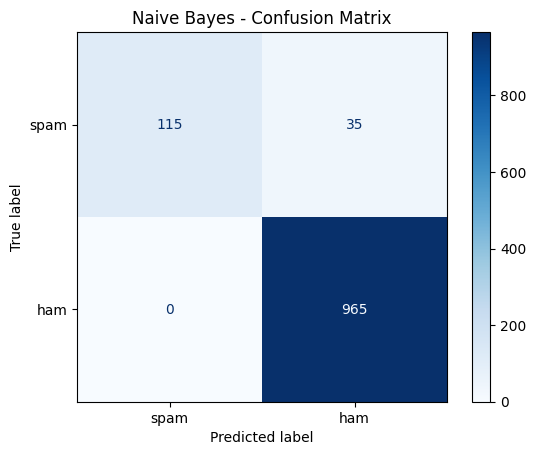

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions, labels=['spam', 'ham'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['spam', 'ham'])
disp.plot(cmap='Blues')
plt.title("Naive Bayes - Confusion Matrix")
plt.show()

### **Random Forest**

In [ ]:
from datasets import load_dataset
import pandas as pd

ds = load_dataset("SetFit/bbc-news")

train_df = ds['train'].to_pandas()
test_df = ds['test'].to_pandas()

print(train_df.shape, test_df.shape)
print(train_df['label_text'].value_counts())

(1225, 3) (1000, 3)
label_text
business         286
sport            275
politics         242
tech             212
entertainment    210
Name: count, dtype: int64


### **Vectorization**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_bbc = TfidfVectorizer(max_features=5000, stop_words='english')

X_train_bbc = tfidf_bbc.fit_transform(train_df['text'])
X_test_bbc = tfidf_bbc.transform(test_df['text'])

y_train_bbc = train_df['label_text']
y_test_bbc = test_df['label_text']

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_bbc = RandomForestClassifier(n_estimators=200, random_state=42)
model_bbc.fit(X_train_bbc, y_train_bbc)

predictions_bbc = model_bbc.predict(X_test_bbc)

### **Accuracy**

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test_bbc, predictions_bbc)
print("Accuracy:", acc)

Accuracy: 0.946


### **Precision**

In [ ]:
from sklearn.metrics import precision_score

prec = precision_score(y_test_bbc, predictions_bbc, average='weighted')
print("Precision:", prec)

Precision: 0.9474094348799033


### **Recall**

In [ ]:
from sklearn.metrics import recall_score

rec = recall_score(y_test_bbc, predictions_bbc, average='weighted')
print("Recall:", rec)

Recall: 0.946


### **F1 Score**

In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test_bbc, predictions_bbc, average='weighted')
print("F1 Score:", f1)

F1 Score: 0.9459844304052625


### **Confusion Matrix**

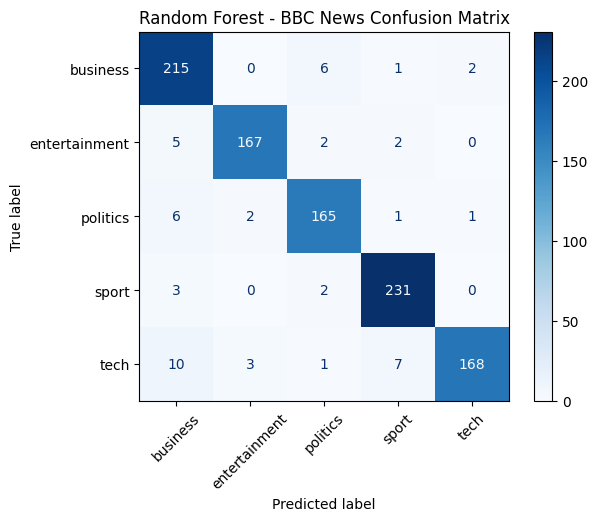

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = sorted(y_test_bbc.unique())
cm = confusion_matrix(y_test_bbc, predictions_bbc, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Random Forest - BBC News Confusion Matrix")
plt.show()

### **SVM**

In [ ]:
from sklearn.datasets import fetch_20newsgroups

categories = ['sci.space', 'rec.sport.baseball', 'talk.politics.guns', 'comp.graphics', 'sci.med']

train_data = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))
test_data = fetch_20newsgroups(subset='test', categories=categories, remove=('headers', 'footers', 'quotes'))

print("Training samples:", len(train_data.data))
print("Test samples:", len(test_data.data))
print("Categories:", train_data.target_names)

Training samples: 2914
Test samples: 1940
Categories: ['comp.graphics', 'rec.sport.baseball', 'sci.med', 'sci.space', 'talk.politics.guns']


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_svm = TfidfVectorizer(max_features=5000, stop_words='english')

X_train_svm = tfidf_svm.fit_transform(train_data.data)
X_test_svm = tfidf_svm.transform(test_data.data)

y_train_svm = train_data.target
y_test_svm = test_data.target

In [ ]:
from sklearn.svm import SVC

model_svm = SVC(kernel='linear', random_state=42)
model_svm.fit(X_train_svm, y_train_svm)

predictions_svm = model_svm.predict(X_test_svm)

### **Accuracy**

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test_svm, predictions_svm)
print("Accuracy:", acc)

Accuracy: 0.8262886597938144


### **Recall**

In [ ]:
from sklearn.metrics import recall_score

rec = recall_score(y_test_svm, predictions_svm, average='weighted')
print("Recall:", rec)

Recall: 0.8262886597938144


### **Precision**

In [ ]:
from sklearn.metrics import precision_score

prec = precision_score(y_test_svm, predictions_svm, average='weighted')
print("Precision:", prec)

Precision: 0.8280180756722589


### **F1 Score**

In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test_svm, predictions_svm, average='weighted')
print("F1 Score:", f1)

F1 Score: 0.8260618325731047


### **Confusion Matrix**

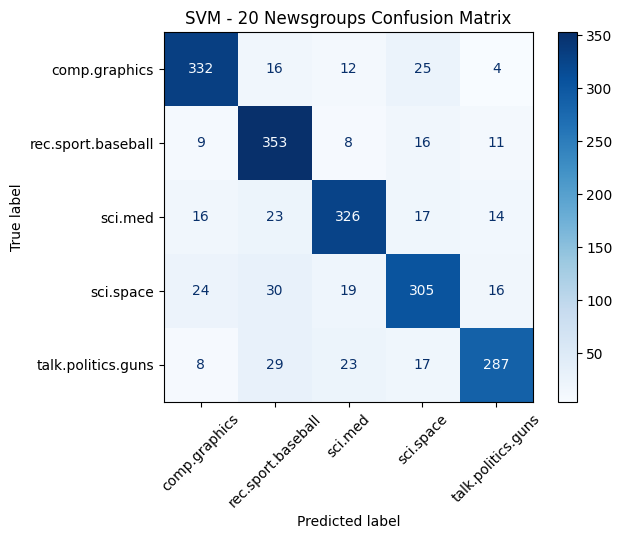

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_svm, predictions_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_data.target_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("SVM - 20 Newsgroups Confusion Matrix")
plt.show()